# Data Cleaning and Preprocessing

This notebook performs comprehensive data cleaning including:
- Loading raw delivery data
- Handling missing values intelligently
- Data validation (coordinates, delivery times, ages)
- Removing duplicates
- Standardizing categorical variables
- Saving cleaned dataset for feature engineering

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Custom null values 
custom_nulls = ["na", "n/a", "NA", "null", "none", "missing", "-", "--", " ", ""]

df = pd.read_csv('/Users/anuragchaubey/MilesAhead/data/amazon_delivery.csv', na_values=custom_nulls)
print(f"Initial data shape: {df.shape}")
df.head()

Initial data shape: (43739, 16)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [4]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nRows with any missing values: {df.isnull().any(axis=1).sum()}")
print(f"Total missing values: {df.isnull().sum().sum()}")

Missing values:
Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

Rows with any missing values: 145
Total missing values: 145


In [6]:
# Inspect rows with missing values
print("Sample rows with missing values:")
df[df.isnull().any(axis=1)].head(20)

Sample rows with missing values:


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
124,uurs547552548,23,NaN,22.569358,88.433452,22.599358,88.463452,2022-02-17,23:25:00,23:35:00,Sunny,Low,motorcycle,Metropolitian,75,Snacks
1996,xoaj834389107,32,NaN,0.000000,0.000000,0.050000,0.050000,2022-02-11,20:50:00,21:00:00,Sandstorms,Jam,motorcycle,Urban,185,Snacks
2002,lasr795083832,23,NaN,25.454648,81.834502,25.584648,81.964502,2022-02-18,19:50:00,19:55:00,Windy,Jam,motorcycle,Metropolitian,150,Outdoors
2018,gjcr517387117,26,NaN,0.000000,0.000000,0.080000,0.080000,2022-02-16,23:50:00,23:55:00,Cloudy,Low,scooter,Metropolitian,140,Clothing
2286,xige084493792,15,1.0,-26.891191,75.802083,26.981191,75.892083,2022-03-12,NaN,17:20:00,NaN,NaN,motorcycle,Urban,75,Home
2779,oilg311747812,15,1.0,22.750040,75.902847,22.810040,75.962847,2022-04-03,NaN,20:30:00,NaN,NaN,scooter,Metropolitian,145,Kitchen
2825,pbox816153129,15,1.0,21.149569,72.772697,21.209569,72.832697,2022-03-21,NaN,22:10:00,NaN,NaN,bicycle,Metropolitian,100,Clothing
3253,ohgx024912559,32,NaN,19.874733,75.353942,19.984733,75.463942,2022-02-16,18:35:00,18:50:00,Sandstorms,Medium,motorcycle,Metropolitian,170,Kitchen
3385,tvng587700125,25,NaN,15.513150,73.783460,15.593150,73.863460,2022-02-18,17:40:00,17:55:00,Sunny,Medium,motorcycle,Urban,115,Clothing
3438,nzsa056960624,50,6.0,-12.970324,-77.645748,13.010324,77.685748,2022-03-13,NaN,12:30:00,NaN,NaN,van,Urban,125,Cosmetics


## Check for Duplicates

In [7]:
# Check for duplicate Order IDs
duplicates = df.duplicated(subset=['Order_ID'], keep=False)
print(f"Duplicate Order IDs found: {duplicates.sum()}")

if duplicates.sum() > 0:
    print("\nDuplicate orders:")
    print(df[duplicates][['Order_ID', 'Order_Date', 'Order_Time', 'Delivery_Time']].head(20))
    
    # Remove duplicates, keep first occurrence
    df = df.drop_duplicates(subset=['Order_ID'], keep='first')
    print(f"\nShape after removing duplicates: {df.shape}")
else:
    print("No duplicates found.")

Duplicate Order IDs found: 0
No duplicates found.


In [9]:
print("=== HANDLING MISSING VALUES ===\n")

# 1. Impute Agent_Rating with median 
missing_rating = df['Agent_Rating'].isnull().sum()
if missing_rating > 0:
    median_rating = df['Agent_Rating'].median()
    df.fillna({'Agent_Rating':median_rating}, inplace=True)
    print(f"✅ Imputed {missing_rating} missing Agent_Rating values with median: {median_rating:.1f}")
else:
    print("✅ No missing Agent_Rating values")

# 2. Impute Weather with mode 
missing_weather = df['Weather'].isnull().sum()
if missing_weather > 0:
    mode_weather = df['Weather'].mode()[0]
    df.fillna({'Weather':mode_weather}, inplace=True)
    print(f"✅ Imputed {missing_weather} missing Weather values with mode: {mode_weather}")
else:
    print("✅ No missing Weather values")

# 3. Drop remaining rows with missing values (should be very few now)
rows_before = len(df)
df = df.dropna()
df.reset_index(drop=True, inplace=True)
rows_dropped = rows_before - len(df)

if rows_dropped > 0:
    print(f"\n⚠️  Dropped {rows_dropped} rows with remaining missing values")
else:
    print("\n✅ No additional rows dropped")

print(f"✅ Final shape: {df.shape}")

=== HANDLING MISSING VALUES ===

✅ No missing Agent_Rating values
✅ No missing Weather values

✅ No additional rows dropped
✅ Final shape: (43739, 16)


## Handle Missing Values Intelligently

Use imputation strategies instead of dropping all rows with missing values

In [10]:
print("=== DATA VALIDATION ===\n")

# 1. Check coordinate ranges (India roughly: lat 8-37, lon 68-97)
invalid_coords = df[
    (df['Store_Latitude'] < 8) | (df['Store_Latitude'] > 37) |
    (df['Store_Longitude'] < 68) | (df['Store_Longitude'] > 97) |
    (df['Drop_Latitude'] < 8) | (df['Drop_Latitude'] > 37) |
    (df['Drop_Longitude'] < 68) | (df['Drop_Longitude'] > 97)
]
print(f"❌ Invalid coordinates (outside India): {len(invalid_coords)}")
if len(invalid_coords) > 0:
    print(invalid_coords[['Order_ID', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude']].head())
    df = df.drop(invalid_coords.index)
    print(f"   Removed {len(invalid_coords)} rows")

# 2. Check delivery time range (should be positive and reasonable < 500 minutes)
invalid_delivery_time = df[(df['Delivery_Time'] <= 0) | (df['Delivery_Time'] > 500)]
print(f"\n❌ Invalid delivery times (≤0 or >500 min): {len(invalid_delivery_time)}")
if len(invalid_delivery_time) > 0:
    print(invalid_delivery_time[['Order_ID', 'Delivery_Time']].head())
    df = df.drop(invalid_delivery_time.index)
    print(f"   Removed {len(invalid_delivery_time)} rows")

# 3. Check agent age (realistic range: 18-70)
invalid_age = df[(df['Agent_Age'] < 18) | (df['Agent_Age'] > 70)]
print(f"\n❌ Invalid agent ages (<18 or >70): {len(invalid_age)}")
if len(invalid_age) > 0:
    print(invalid_age[['Order_ID', 'Agent_Age']].head())
    df = df.drop(invalid_age.index)
    print(f"   Removed {len(invalid_age)} rows")

# 4. Check for same pickup and drop locations (zero distance)
same_location = df[
    (df['Store_Latitude'] == df['Drop_Latitude']) & 
    (df['Store_Longitude'] == df['Drop_Longitude'])
]
print(f"\n❌ Same pickup and drop location: {len(same_location)}")
if len(same_location) > 0:
    df = df.drop(same_location.index)
    print(f"   Removed {len(same_location)} rows")

# Reset index after removals
df.reset_index(drop=True, inplace=True)

print(f"\n✅ Shape after validation: {df.shape}")

=== DATA VALIDATION ===

❌ Invalid coordinates (outside India): 3693
         Order_ID  Store_Latitude  Store_Longitude  Drop_Latitude  \
33  zotl583816092             0.0              0.0           0.11   
51  dcdm719150402             0.0              0.0           0.03   
56  bbow373480117             0.0              0.0           0.08   
58  etss702593505             0.0              0.0           0.06   
66  emlt327861941             0.0              0.0           0.02   

    Drop_Longitude  
33            0.11  
51            0.03  
56            0.08  
58            0.06  
66            0.02  
   Removed 3693 rows

❌ Invalid delivery times (≤0 or >500 min): 0

❌ Invalid agent ages (<18 or >70): 25
            Order_ID  Agent_Age
2779   oilg311747812         15
2825   pbox816153129         15
5659   pjec796867569         15
8783   ebhx017527500         15
10466  loqy430001953         15
   Removed 25 rows

❌ Same pickup and drop location: 0

✅ Shape after validation: (40021, 16

## Data Validation

Validate data ranges and remove invalid records

In [11]:
# Verify no missing values remain
print("Missing values after cleaning:")
missing_check = df.isnull().sum()
print(missing_check)

if missing_check.sum() == 0:
    print("\n✅ SUCCESS: No missing values in the dataset!")
else:
    print(f"\n⚠️  WARNING: Still {missing_check.sum()} missing values found")

Missing values after cleaning:
Order_ID           0
Agent_Age          0
Agent_Rating       0
Store_Latitude     0
Store_Longitude    0
Drop_Latitude      0
Drop_Longitude     0
Order_Date         0
Order_Time         0
Pickup_Time        0
Weather            0
Traffic            0
Vehicle            0
Area               0
Delivery_Time      0
Category           0
dtype: int64

✅ SUCCESS: No missing values in the dataset!


In [12]:
print("Current data types:")
print(df.dtypes)

Current data types:
Order_ID            object
Agent_Age            int64
Agent_Rating       float64
Store_Latitude     float64
Store_Longitude    float64
Drop_Latitude      float64
Drop_Longitude     float64
Order_Date          object
Order_Time          object
Pickup_Time         object
Weather             object
Traffic             object
Vehicle             object
Area                object
Delivery_Time        int64
Category            object
dtype: object


## convert columns to appropriate data types

In [13]:
# Convert 'Order_Date' to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
print(f"✅ Order_Date converted to datetime")
print(f"   Date range: {df['Order_Date'].min()} to {df['Order_Date'].max()}")

✅ Order_Date converted to datetime
   Date range: 2022-02-11 00:00:00 to 2022-04-06 00:00:00


In [14]:
# Keep Order_Time as string format (HH:MM:SS)
# feature engineering pipeline will handle datetime conversion
# DO NOT convert Order_Time or Pickup_Time here

print("✅ Order_Time kept as string format for feature engineering pipeline")
print(f"   Sample Order_Time values: {df['Order_Time'].head(3).tolist()}")

# Note: Pickup_Time will be REMOVED from final dataset to prevent data leakage

✅ Order_Time kept as string format for feature engineering pipeline
   Sample Order_Time values: ['11:30:00', '19:45:00', '08:30:00']


In [15]:
# Convert categorical text columns and standardize to lowercase
# Lowercase is critical for consistency with encoding pipeline
cat_cols = ['Weather', 'Traffic', 'Vehicle', 'Area', 'Category']

print("Converting and standardizing categorical columns:\n")
for col in cat_cols:
    # Convert to string, strip whitespace, convert to lowercase
    df[col] = df[col].astype(str).str.strip().str.lower()
    df[col] = df[col].astype('category')
    print(f"✅ {col}: {df[col].nunique()} unique values")
    print(f"   Values: {sorted(df[col].unique())}")
    print()

Converting and standardizing categorical columns:

✅ Weather: 6 unique values
   Values: ['cloudy', 'fog', 'sandstorms', 'stormy', 'sunny', 'windy']

✅ Traffic: 5 unique values
   Values: ['high', 'jam', 'low', 'medium', 'nan']

✅ Vehicle: 4 unique values
   Values: ['bicycle', 'motorcycle', 'scooter', 'van']

✅ Area: 4 unique values
   Values: ['metropolitian', 'other', 'semi-urban', 'urban']

✅ Category: 16 unique values
   Values: ['apparel', 'books', 'clothing', 'cosmetics', 'electronics', 'grocery', 'home', 'jewelry', 'kitchen', 'outdoors', 'pet supplies', 'shoes', 'skincare', 'snacks', 'sports', 'toys']



In [16]:
print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
Order_ID                   object
Agent_Age                   int64
Agent_Rating              float64
Store_Latitude            float64
Store_Longitude           float64
Drop_Latitude             float64
Drop_Longitude            float64
Order_Date         datetime64[ns]
Order_Time                 object
Pickup_Time                object
Weather                  category
Traffic                  category
Vehicle                  category
Area                     category
Delivery_Time               int64
Category                 category
dtype: object


In [17]:
# Verify categorical values are properly formatted
print("=== CATEGORICAL VALUE VERIFICATION ===\n")
print(f"Weather values: {sorted(df['Weather'].unique())}")
print(f"Weather counts:\n{df['Weather'].value_counts()}\n")

=== CATEGORICAL VALUE VERIFICATION ===

Weather values: ['cloudy', 'fog', 'sandstorms', 'stormy', 'sunny', 'windy']
Weather counts:
Weather
fog           6808
stormy        6757
cloudy        6676
sandstorms    6652
windy         6624
sunny         6504
Name: count, dtype: int64



In [18]:
print(f"Vehicle values: {sorted(df['Vehicle'].unique())}")
print(f"Vehicle counts:\n{df['Vehicle'].value_counts()}\n")

Vehicle values: ['bicycle', 'motorcycle', 'scooter', 'van']
Vehicle counts:
Vehicle
motorcycle    23461
scooter       13367
van            3191
bicycle           2
Name: count, dtype: int64



In [19]:
print(f"Traffic values: {sorted(df['Traffic'].unique())}")
print(f"Traffic counts:\n{df['Traffic'].value_counts()}\n")

Traffic values: ['high', 'jam', 'low', 'medium', 'nan']
Traffic counts:
Traffic
low       13699
jam       12610
medium     9755
high       3933
nan          24
Name: count, dtype: int64



In [20]:
print(f"Area values: {sorted(df['Area'].unique())}")
print(f"Area counts:\n{df['Area'].value_counts()}\n")

Area values: ['metropolitian', 'other', 'semi-urban', 'urban']
Area counts:
Area
metropolitian    29966
urban             8869
other             1048
semi-urban         138
Name: count, dtype: int64



In [21]:
print(f"Category values: {sorted(df['Category'].unique())}")
print(f"Category counts:\n{df['Category'].value_counts()}")

Category values: ['apparel', 'books', 'clothing', 'cosmetics', 'electronics', 'grocery', 'home', 'jewelry', 'kitchen', 'outdoors', 'pet supplies', 'shoes', 'skincare', 'snacks', 'sports', 'toys']
Category counts:
Category
electronics     2613
jewelry         2573
books           2571
toys            2563
skincare        2555
outdoors        2532
snacks          2511
apparel         2497
sports          2473
home            2472
pet supplies    2460
cosmetics       2451
grocery         2447
kitchen         2440
shoes           2440
clothing        2423
Name: count, dtype: int64


In [22]:
# Statistical summary of numerical columns
print("=== STATISTICAL SUMMARY ===\n")
print(df.describe())

=== STATISTICAL SUMMARY ===

          Agent_Age  Agent_Rating  Store_Latitude  Store_Longitude  \
count  40021.000000  40021.000000    40021.000000     40021.000000   
mean      29.564629      4.634887       18.900840        76.913187   
min       20.000000      2.500000        9.957144        72.768726   
25%       25.000000      4.500000       12.986047        73.897902   
50%       30.000000      4.700000       19.065838        76.618203   
75%       35.000000      4.900000       22.751234        78.347554   
max       50.000000      6.000000       30.914057        88.433452   
std        5.781949      0.316451        5.464886         3.492637   

       Drop_Latitude  Drop_Longitude                     Order_Date  \
count   40021.000000    40021.000000                          40021   
mean       18.964482       76.976829  2022-03-14 06:50:17.555783424   
min         9.967144       72.778726            2022-02-11 00:00:00   
25%        13.065662       73.939315            2022-03-

## Save Cleaned Dataset

**CRITICAL:** Remove Pickup_Time to prevent data leakage!

In [23]:
print("=== FINAL CLEANED DATASET INFO ===\n")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")
print(f"Delivery time range: {df['Delivery_Time'].min()} to {df['Delivery_Time'].max()} minutes")
print(f"  Mean: {df['Delivery_Time'].mean():.1f} min, Median: {df['Delivery_Time'].median():.1f} min")
print(f"Agent age range: {df['Agent_Age'].min()} to {df['Agent_Age'].max()} years")
print(f"Agent rating range: {df['Agent_Rating'].min():.1f} to {df['Agent_Rating'].max():.1f}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

=== FINAL CLEANED DATASET INFO ===

Shape: 40,021 rows × 16 columns
Date range: 2022-02-11 to 2022-04-06
Delivery time range: 10 to 270 minutes
  Mean: 125.1 min, Median: 125.0 min
Agent age range: 20 to 50 years
Agent rating range: 2.5 to 6.0

Memory usage: 9.35 MB


## Final Dataset Summary

In [27]:
# Exclude Pickup_Time to prevent data leakage
# Pickup_Time is only known AFTER the order is picked up, not at prediction time

columns_to_save = [
    'Order_ID', 'Agent_Age', 'Agent_Rating',
    'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude',
    'Order_Date', 'Order_Time',  
    'Weather', 'Traffic', 'Vehicle', 'Area', 'Delivery_Time', 'Category'
]

df_final = df[columns_to_save].copy()

# Save cleaned data - using relative path from notebook location
import os
output_path = '../data/processed/delivery_data_cleaned.csv'

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df_final.to_csv(output_path, index=False)

print(f"✅ CLEANED DATA SAVED SUCCESSFULLY!")
print(f"   Path: {os.path.abspath(output_path)}")
print(f"   Shape: {df_final.shape[0]:,} rows × {df_final.shape[1]} columns")
print(f"\nColumns included: {list(df_final.columns)}")
print(f"\n⚠️  NOTE: Pickup_Time was REMOVED to prevent data leakage")

✅ CLEANED DATA SAVED SUCCESSFULLY!
   Path: /Users/anuragchaubey/MilesAhead/data/processed/delivery_data_cleaned.csv
   Shape: 40,021 rows × 15 columns

Columns included: ['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date', 'Order_Time', 'Weather', 'Traffic', 'Vehicle', 'Area', 'Delivery_Time', 'Category']

⚠️  NOTE: Pickup_Time was REMOVED to prevent data leakage


## Summary of Changes Made

**Data Cleaning Improvements:**
1. ✅ Smart imputation for missing values (Agent_Rating: median, Weather: mode)
2. ✅ Data validation for coordinates, delivery times, and agent ages
3. ✅ Duplicate removal based on Order_ID
4. ✅ Removal of same pickup/drop location orders
5. ✅ Case standardization (lowercase) for all categorical variables
6. ✅ **CRITICAL:** Removed Pickup_Time to prevent data leakage
7. ✅ Comprehensive logging and verification
8. ✅ Visualization of key distributions

**Next Steps:**
1. Create OSRM distance extraction script (if not already done)
2. Fix feature engineering pipeline (remove pickup-related features)
3. Update encoding pipeline
4. Retrain the model

✅ Visualization saved to: /Users/anuragchaubey/MilesAhead/outputs/data_cleaning_summary.png


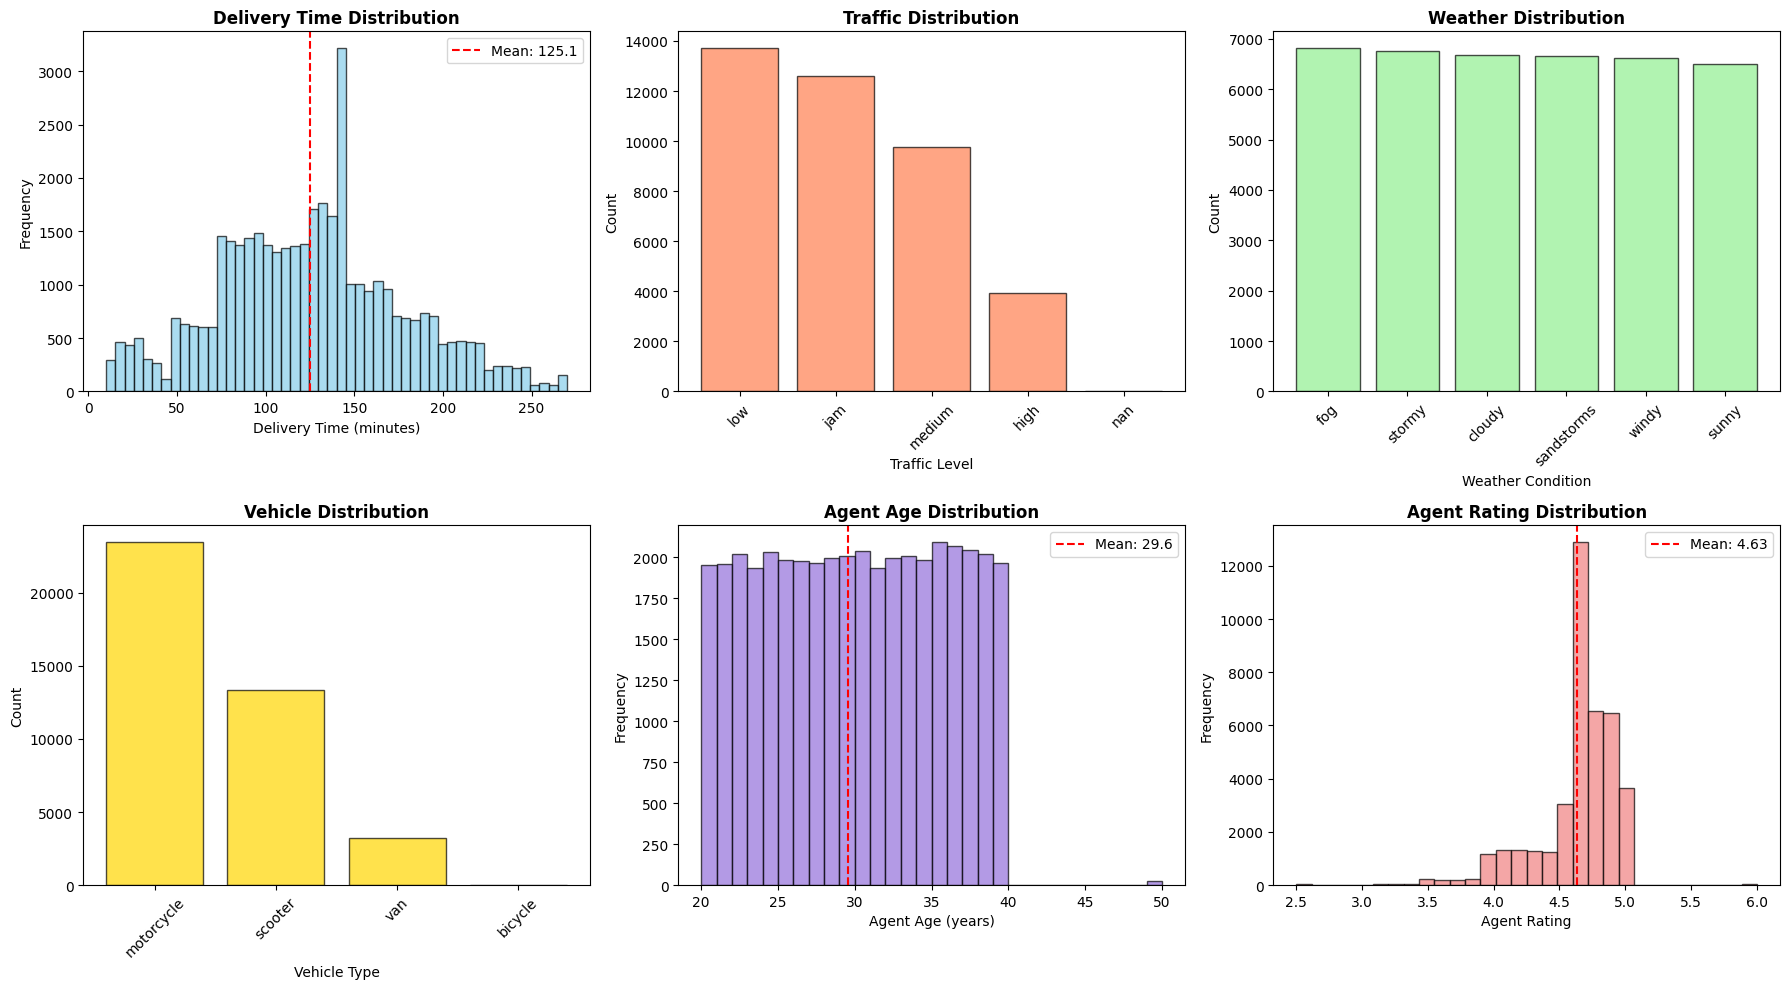

In [28]:
import os

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Delivery time distribution
axes[0, 0].hist(df_final['Delivery_Time'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Delivery Time Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Delivery Time (minutes)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_final['Delivery_Time'].mean(), color='red', linestyle='--', label=f'Mean: {df_final["Delivery_Time"].mean():.1f}')
axes[0, 0].legend()

# 2. Traffic distribution
traffic_counts = df_final['Traffic'].value_counts()
axes[0, 1].bar(traffic_counts.index, traffic_counts.values, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Traffic Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Traffic Level')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Weather distribution
weather_counts = df_final['Weather'].value_counts()
axes[0, 2].bar(weather_counts.index, weather_counts.values, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Weather Distribution', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Weather Condition')
axes[0, 2].set_ylabel('Count')
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. Vehicle distribution
vehicle_counts = df_final['Vehicle'].value_counts()
axes[1, 0].bar(vehicle_counts.index, vehicle_counts.values, color='gold', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Vehicle Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Vehicle Type')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Agent age distribution
axes[1, 1].hist(df_final['Agent_Age'], bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Agent Age Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Agent Age (years)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(df_final['Agent_Age'].mean(), color='red', linestyle='--', label=f'Mean: {df_final["Agent_Age"].mean():.1f}')
axes[1, 1].legend()

# 6. Agent rating distribution
axes[1, 2].hist(df_final['Agent_Rating'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Agent Rating Distribution', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Agent Rating')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].axvline(df_final['Agent_Rating'].mean(), color='red', linestyle='--', label=f'Mean: {df_final["Agent_Rating"].mean():.2f}')
axes[1, 2].legend()

plt.tight_layout()

# Save visualization - using relative path from notebook location
viz_output_path = '../outputs/data_cleaning_summary.png'
os.makedirs(os.path.dirname(viz_output_path), exist_ok=True)
plt.savefig(viz_output_path, dpi=300, bbox_inches='tight')
print(f"✅ Visualization saved to: {os.path.abspath(viz_output_path)}")
plt.show()